In [67]:
import os
from dotenv import load_dotenv

from timex.ecg import dataset, tokenizer

from tslearn.piecewise import OneD_SymbolicAggregateApproximation, SymbolicAggregateApproximation
from torch.utils.data import DataLoader

from transformers import (
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    BigBirdForMaskedLM,
    BigBirdForPreTraining,
    BigBirdConfig
)

import numpy as np
import gc

from tqdm import tqdm

import matplotlib.pyplot as plt

load_dotenv('../.env')
BASE_DIR = os.getenv('ECG_DIR')

In [114]:
SAX1d = OneD_SymbolicAggregateApproximation(n_segments=256, alphabet_size_avg=512, alphabet_size_slope=31, 
                                            scale=False)
SAA = SymbolicAggregateApproximation(n_segments=256, alphabet_size_avg=512, 
                                     scale=False)

In [4]:
PREPLIST = ['savgol', 'resampler', 'notch', 'bandpass'] #, 'detrend', 'peak_trimming']

In [7]:
ECGDat = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                       'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
                                       'records500',
                                       '00000'),
                       label_binarizer=None,
                       augmentations=[],                       
                       encode=False,
                       pretrain=False,
                       preprocessing=PREPLIST)

ECGDl_prep = DataLoader(ECGDat, batch_size=128, shuffle=False, collate_fn=ECGDat.collate)

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


In [45]:
# collect data for fitting
ecgConfig = dataset.Config
ecgConfig.SAMPLING_RATE = 500

results = []
for batch in tqdm(ECGDl_prep, desc="Processing ECG batches"):
    ecg_data, ecg_label, ecg_filenames, _ , ecg_metadata = batch
    for signal, label, metadata, filename in zip(ecg_data, ecg_label, ecg_metadata, ecg_filenames):
        results.append(np.array(signal).transpose())

Processing ECG batches: 100%|██████████| 8/8 [00:28<00:00,  3.54s/it]


In [115]:
SAA.fit(results, y=None)
SAX1d.fit(results, y=None)
#del results
#gc.collect()

OneD_SymbolicAggregateApproximation(alphabet_size_avg=512,
                                    alphabet_size_slope=31, n_segments=256)

In [116]:
sym_test = SAA.transform([results[0]])
inv_sym_test = SAA.inverse_transform(sym_test)[0]

sym_test_1d = SAX1d.transform([results[0]])
inv_sym_test_1d = SAX1d.inverse_transform(sym_test_1d)[0]


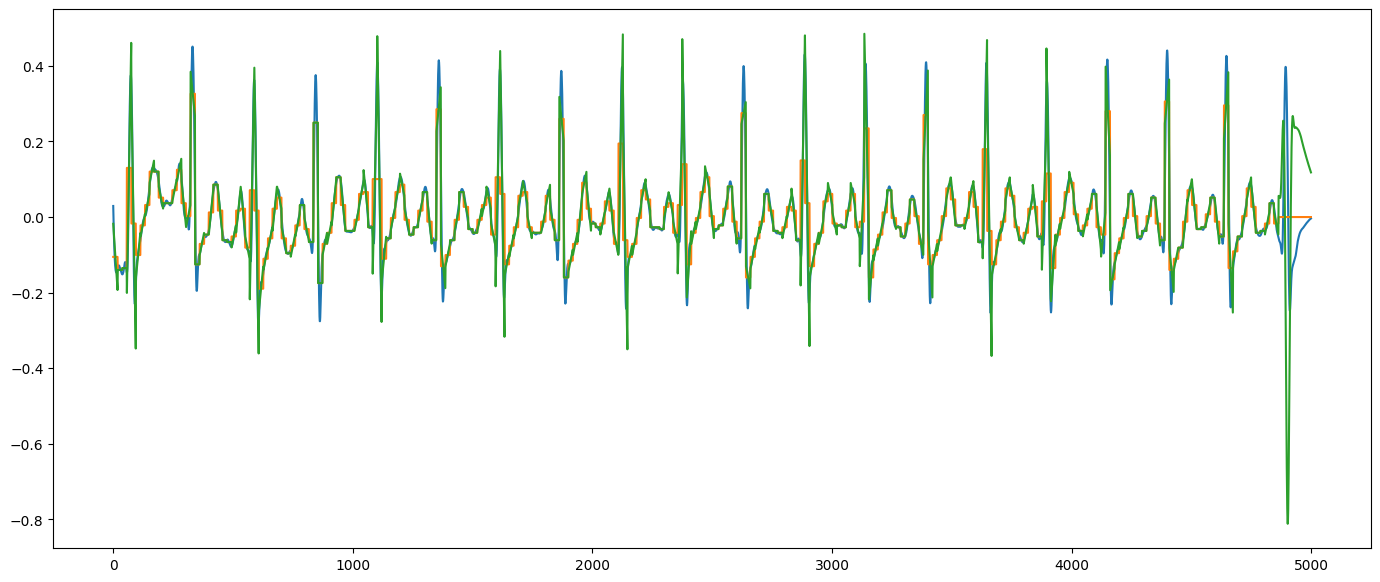

In [118]:
channel = 0
fig,ax=plt.subplots(figsize=(17,7))
plt.plot(results[0][:, channel])
plt.plot(inv_sym_test[:, channel])
plt.plot(inv_sym_test_1d[:, channel])

In [ ]:
ECGTok = tokenizer.ECGTokenizer(SAX_List=SAA)
ECGDc = DataCollatorForLanguageModeling(ECGTok, mlm=True)
ECGDl = DataLoader(ECGDat, batch_size=128, shuffle=False, collate_fn=ECGDc)

NotFittedError: This SymbolicAggregateApproximation instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [27]:
model_config = BigBirdConfig.from_pretrained('google/bigbird-roberta-base')
model_config.bos_token_id = ECGTok.bos_token_id
model_config.eos_token_id = ECGTok.eos_token_id
model_config.pad_token_id = ECGTok.pad_token_id
model_config.cls_token_id = ECGTok.cls_token_id
model_config.sep_token_id = ECGTok.sep_token_id
model_config.mask_token_id = ECGTok.mask_token_id
model_config.vocab_size = ECGTok.vocab_size

print(f"Tokenizer vocab_size: {ECGTok.vocab_size}")
print(f"Special token IDs:")
print(f"  bos_token_id: {model_config.bos_token_id}")
print(f"  eos_token_id: {model_config.eos_token_id}")
print(f"  pad_token_id: {model_config.pad_token_id}")
print(f"  cls_token_id: {model_config.cls_token_id}")
print(f"  sep_token_id: {model_config.sep_token_id}")
print(f"  mask_token_id: {model_config.mask_token_id}")

RecursionError: maximum recursion depth exceeded while calling a Python object

In [ ]:
ECGModel = BigBirdForPreTraining(model_config)

In [ ]:
ECGTrainer = Trainer(model=)